In [128]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("../data/github_tech_radar_results.csv")

In [152]:
df["growth_rate_label"] = df["growth_rate"].apply(
    lambda x: f"{x:+.2f}%" if pd.notnull(x) else "New Repository"
)

df['growth_rate_plot'] = df['growth_rate'].fillna(0)

min_score = df['momentum_score'].min()
df['visual_size'] = df['momentum_score'] - min_score + 1

# GitHub Technology Radar Dashboard

## Chart 1: Momentum Ranking

This chart ranks repositories by momentum score to identify which open-source technologies show the strongest short-term activity signals.

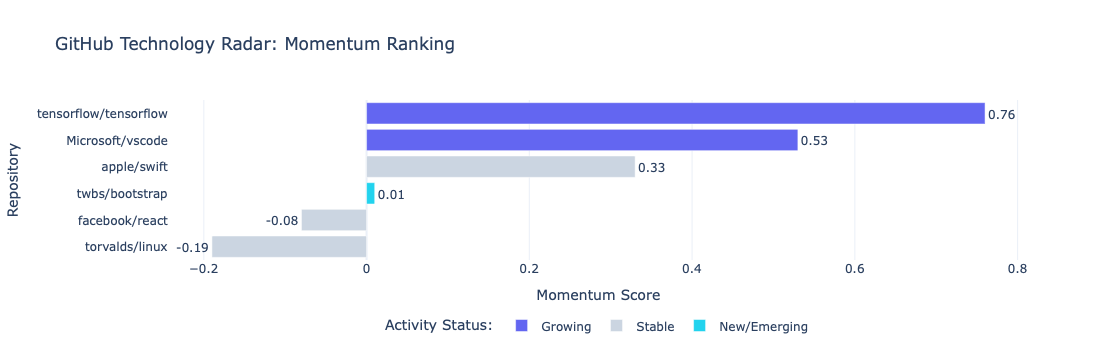

In [208]:
fig=px.bar(df,x="momentum_score", 
           y="repo_name", title="GitHub Technology Radar: Momentum Ranking",orientation='h', 
           color="activity_status",
          color_discrete_map={
  "Growing": "#6366F1",
  "Stable" :  "#CBD5E1",
  "New/Emerging": "#22D3EE"
},
custom_data=["repo_name","momentum_score", 
             "growth_rate_label", "contributor_count", "activity_status"]
)


fig.update_layout(template="plotly_white", yaxis={'categoryorder':'total ascending'}, 
                  xaxis_title="Momentum Score", yaxis_title="Repository",
                  legend_title="Activity Status:",
legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.5,
        xanchor="center",
        x=0.5,
maxheight=0.1),
                 margin=dict(b=100) 
                 
)


fig.update_traces(
    texttemplate='%{x:.2f}',      # Shows the x-value as the label
    textposition='outside', # Places the label next to the bar
    hovertemplate="<b>%{customdata[0]}</b><br><br>" + "Momentum Score: %{customdata[1]:.2f}<br>" +
    "Growth Rate: %{customdata[2]}%<br>" + "Contributors: %{customdata[3]}</b><br><br>" 
    + "Status: %{customdata[4]}" + "<extra></extra>"
)


fig.show()

In [ ]:
fig.write_image("../images/momentum_ranking.png", width=1400, height=800)

### Key Insight

TensorFlow and VS Code show the strongest momentum signals, while Linux demonstrates that a large contributor base does not necessarily translate into positive short-term momentum.

In [ ]:
!pip install -U kaleido

## Chart 2: What Drives Technology Momentum?

While Chart 1 identifies the highest-momentum repositories, this visualization explains the drivers behind that momentum. By comparing repository growth, contributor activity, and momentum simultaneously, we can distinguish between mature ecosystems, emerging technologies, and rapidly accelerating projects.

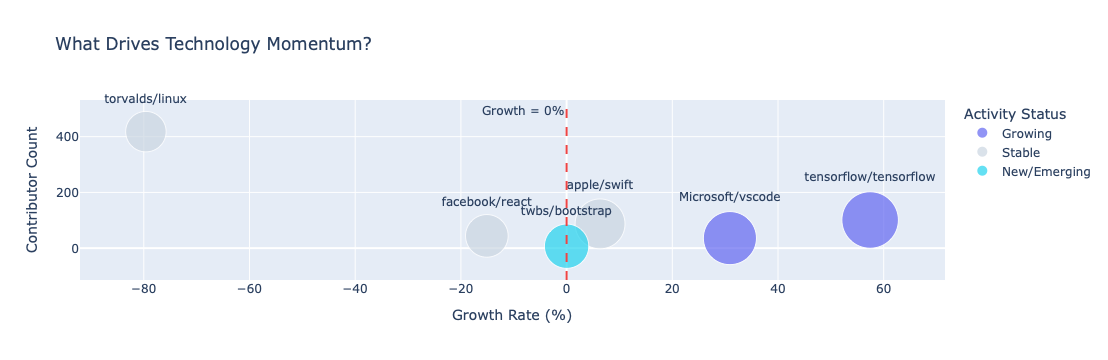

In [207]:
fig2=px.scatter(df, x="growth_rate_plot", y="contributor_count", title="What Drives Technology Momentum?", 
           color="activity_status", labels={'growth_rate_plot':'Growth Rate (%)', 'contributor_count':'Contributor Count', 'activity_status':'Activity Status'},
                size="visual_size",  size_max=40,  text="repo_name",
          color_discrete_map={
  "Growing": "#6366F1",
  "Stable" :  "#CBD5E1",
  "New/Emerging": "#22D3EE"
},
          custom_data=["repo_name","momentum_score",
                       "growth_rate_label",
                       "contributor_count", "activity_status"]
)



fig2.update_traces( textposition="top center",  
                    hovertemplate="<b>%{customdata[0]}</b><br><br>"  +
    "Growth Rate: %{customdata[2]}<br>" + "Contributors: %{customdata[3]}</b><br><br>"
                    + "Momentum Score: %{customdata[1]:.2f}<br>"
    + "Status: %{customdata[4]}" + "<extra></extra>", cliponaxis=False )


fig2.add_vline(x=0, 
    line_width=2, 
    line_dash="dash", 
    line_color="#EF4444",  # Soft Red 
               annotation_text="Growth = 0%",
    annotation_position="top left"
)



fig2.show()






In [ ]:
fig2.write_image("../images/momentum_drivers.png", width=1400, height=800)

### Key Insight

Momentum is influenced by both growth and contributor activity. TensorFlow combines strong growth with a meaningful contributor base, while Linux maintains the largest contributor community despite negative short-term growth. Bootstrap appears as an emerging repository with limited historical baseline.

# Chart 3: Repository Discovery Radar

This visualization extends the momentum analysis by combining repository growth and ecosystem participation into a single Repository Radar Score. By comparing repository momentum against ecosystem strength, we can classify technologies into actionable radar zones—Adopt / Scale, Trial / Investigate, Hold / Monitor, and Watch. This approach helps distinguish established technologies from emerging opportunities and prioritize areas for further exploration.


In [209]:
radar_df = pd.read_csv(
    "../data/chart3_repository_radar_classification_dataset.csv"
)

In [210]:
radar_df["growth_rate_label"] = radar_df["growth_rate"].apply(
    lambda x: f"{x:+.2f}%" if pd.notnull(x) else "New Repository"
)

radar_df['growth_rate_plot'] = radar_df['growth_rate'].fillna(0)


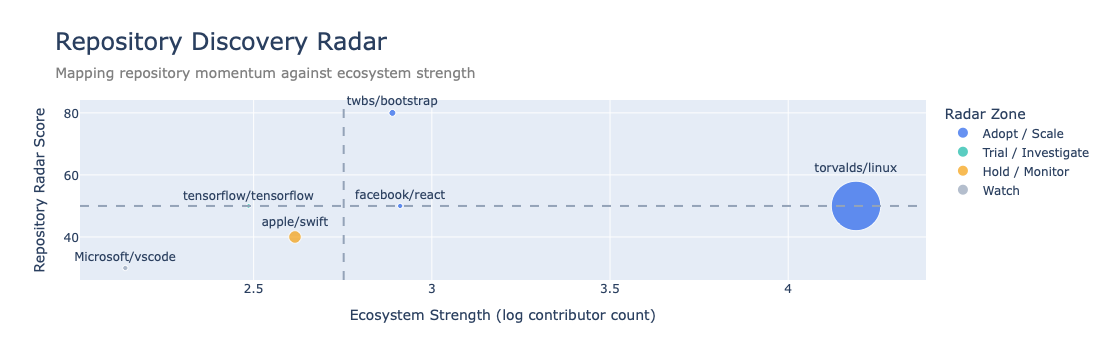

In [205]:
fig3=px.scatter(radar_df, x="log_contributor_count", y="Repository_radar_score", 
           color="radar_zone", labels={'log_contributor_count':'Ecosystem Strength (log contributor count)', 'Repository_radar_score':'Repository Radar Score', 'radar_zone': 'Radar Zone'},
                size="total_commits",  size_max=35,  text="repo_name",
          color_discrete_map={
  "Adopt / Scale": "#2563EB",
  "Trial / Investigate":"#14B8A6",
  "Hold / Monitor": "#F59E0B",
    "Watch": "#94A3B8"

},
          custom_data=["repo_name","contributor_count",
                       "total_commits",
                       "growth_rate_label", "adjusted_growth_rate", 
                       "Repository_radar_score", "radar_zone"]
)


fig3.update_layout(
    title=dict(
        text="Repository Discovery Radar",
        font=dict(size=24)
    ,
        subtitle=dict(
            text="Mapping repository momentum against ecosystem strength",
            font=dict(color="gray", size=14)
        )),
        margin=dict(t=100)
        
    )




fig3.update_traces( textposition="top center",  
                    hovertemplate="<b>%{customdata[0]}</b><br>"  
                    + "Repo Radar Score: %{customdata[5]}<br>" + "Contributor Count: %{customdata[1]}<br>"
                    + "Total Commits: %{customdata[2]}<br>" 
                    + "Growth Rate: %{customdata[3]}<br>"
                    + "Adjusted Growth Rate: %{customdata[4]:.2f}<br>"
                    +  "Radar Zone: %{customdata[6]}"
                                        +"<extra></extra>", cliponaxis=False )



fig3.add_vline(x=median_log_contributor_count, line_width=2, line_dash="dash", 
               line_color="#94A3B8" 
)





fig3.add_hline(y=median_radar_score, line_width=2, 
               line_dash="dash", line_color="#94A3B8" 
)


fig3.show()



In [ ]:
fig3.write_image(
    "../images/repository_discovery_radar.png",
    width=1400,
    height=800
)

### Key Insight

The Repository Discovery Radar classifies repositories by combining short-term momentum with ecosystem strength. Bootstrap appears as the strongest radar signal due to new activity after a zero-activity baseline, while Linux remains ecosystem-heavy but momentum-neutral. TensorFlow falls into Trial / Investigate, reflecting meaningful momentum with a comparatively smaller contributor base.